In [2]:
from importlib.resources import files
from nsbutils.plotting import plot_surf
from neuromodes import EigenSolver
import numpy as np
import matplotlib.pyplot as plt
from lapy.diffgeo import compute_geodesic_f
from lapy.heat import diffusion
import potpourri3d as pp3d

### Setup

In [3]:
init_vert = 0

In [4]:
sphere_path = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-32k_hemi-L_sphere.surf.gii'
cortex_path = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii'

In [5]:
solver = EigenSolver(sphere_path)

### Logarithmic map

In [6]:
heatsolver = pp3d.MeshVectorHeatSolver(solver.geometry.v, solver.geometry.t)

In [42]:
logmap = heatsolver.compute_log_map(init_vert)

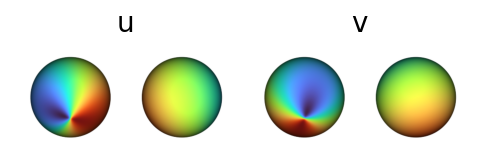

In [43]:
plot_surf(sphere_path, logmap, labels=['u', 'v'], cmap='turbo')

### Geodesic trace

In [44]:
# Try tracing a geodesic from init_vert to another vertex, say 1000
target_vert = 1000
tracer = pp3d.GeodesicTracer(solver.geometry.v, solver.geometry.t)

In [45]:
trace_pts = tracer.trace_geodesic_from_vertex(init_vert, solver.geometry.v[target_vert])
trace_pts.shape  # (n_pts, 3)

(75, 3)

In [46]:
# get vertices that are closest to the trace points
from scipy.spatial import cKDTree
tree = cKDTree(solver.geometry.v)
_, closest_verts = tree.query(trace_pts)

pts_arr = np.zeros((solver.geometry.v.shape[0],))
pts_arr[closest_verts] = 1

In [47]:
# plot distances from init_vert and target_vert
heats = diffusion(solver.geometry, [[init_vert], [target_vert]])

In [48]:
dists = compute_geodesic_f(solver.geometry, heats)

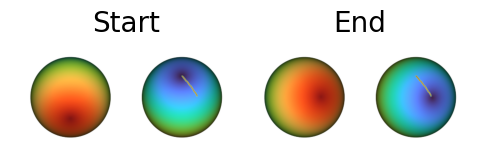

In [36]:
# overlay the geodesic trace on the distance plot
dists_overlay = dists.copy()
dists_overlay[closest_verts] = np.max(dists) + 1
plot_surf(sphere_path, dists_overlay, labels=['Start', 'End'], cmap='turbo')

### Define patch and compute tangent basis

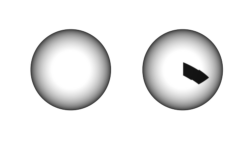

In [49]:
patch_ids = np.arange(target_vert, target_vert + 500)
patch_map = np.zeros((solver.n_verts,))
patch_map[patch_ids] = 1
plot_surf(sphere_path, patch_map, cmap='binary')

In [68]:
# get basis vectors
polygonsolver = pp3d.PolygonMeshHeatSolver(solver.geometry.v, solver.geometry.t)
basisX, basisY, basisN = polygonsolver.get_tangent_frames()  # shapes (n_verts, 3)

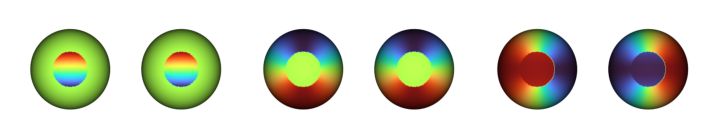

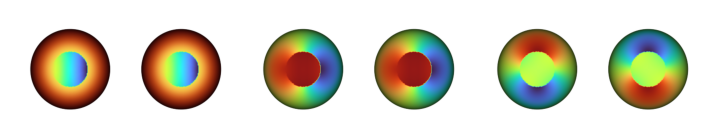

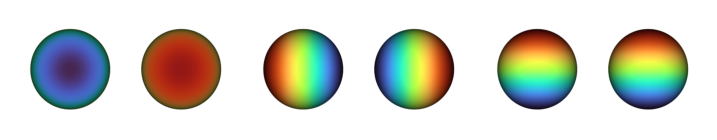

In [69]:
# visualize the basis vectors
plot_surf(sphere_path, basisX, cmap='turbo')
plot_surf(sphere_path, basisY, cmap='turbo')
plot_surf(sphere_path, basisN, cmap='turbo')

## Compute and apply update vector

In [54]:
update_vector = 1/len(patch_ids) * logmap[patch_ids].sum(axis=0)
update_vector

array([-11.40602171,  71.34924766])

In [71]:
# change update_vector from (u, v) tangent space to 3D space, then get corresponding vertex on the
# surface
update_vector_3d = update_vector[0] * basisX[init_vert] + update_vector[1] * basisY[init_vert]
update_vector_3d

array([ 37.51051932,  11.40602171, -60.6932952 ])

In [72]:
# get closest vertex to the update_vector
new_vert = tree.query(solver.geometry.v[init_vert] + update_vector_3d)[1]
new_vert

1346

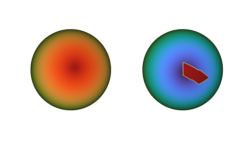

In [ ]:
# plot distance from new_vert and overlay the patch
dists_new_overlay = compute_geodesic_f(solver.geometry, diffusion(solver.geometry, [new_vert]))
dists_new_overlay[patch_ids] = np.max(dists_new_overlay) + 1

plot_surf(sphere_path, dists_new_overlay, cmap='turbo')

## Iteration 2

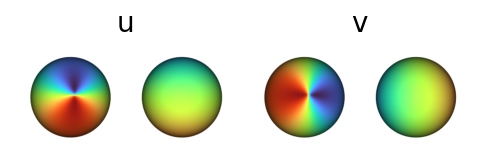

In [76]:
# compute new logmap
logmap = heatsolver.compute_log_map(new_vert)
plot_surf(sphere_path, logmap, labels=['u', 'v'], cmap='turbo')

In [77]:
# new update vector
update_vector = 1/len(patch_ids) * logmap[patch_ids].sum(axis=0)
update_vector_3d = update_vector[0] * basisX[new_vert] + update_vector[1] * basisY[new_vert]
update_vector_3d

array([-2.35723906, 20.28516049, -5.45148835])

In [78]:
# get new vertex
new_vert = tree.query(solver.geometry.v[new_vert] + update_vector_3d)[1]
new_vert

1270

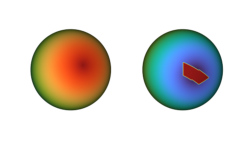

In [79]:
# plot the new vertex's distmap against patch
dists_new_overlay = compute_geodesic_f(solver.geometry, diffusion(solver.geometry, [new_vert]))
dists_new_overlay[patch_ids] = np.max(dists_new_overlay) + 1
plot_surf(sphere_path, dists_new_overlay, cmap='turbo')

### Iteration 3

In [86]:
logmap = heatsolver.compute_log_map(new_vert)
update_vector = 1/len(patch_ids) * logmap[patch_ids].sum(axis=0)
update_vector_3d = update_vector[0] * basisX[new_vert] + update_vector[1] * basisY[new_vert]
new_vert = tree.query(solver.geometry.v[new_vert] + update_vector_3d)[1]

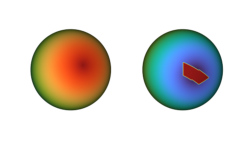

In [87]:
dists_new_overlay = compute_geodesic_f(solver.geometry, diffusion(solver.geometry, [new_vert]))
dists_new_overlay[patch_ids] = np.max(dists_new_overlay) + 1
plot_surf(sphere_path, dists_new_overlay, cmap='turbo')

### Reusable function

In [147]:
def karcher_mean(geometry, patch_ids, init_vert = 0, n_iters=10, heatsolver=None):
    if heatsolver is None:
        heatsolver = pp3d.MeshVectorHeatSolver(geometry.v, geometry.t)
    basisX, basisY, _ = heatsolver.get_tangent_frames()

    print('Done computing heat solver and tangent frames.')
    tree = cKDTree(geometry.v)
    current_vert = init_vert

    print('Done initializing tree and current vertex.')

    iter_verts = np.empty((n_iters,), dtype=int)
    for i in range(n_iters):
        logmap = heatsolver.compute_log_map(current_vert)
        update_vector = 1/len(patch_ids) * logmap[patch_ids].sum(axis=0)
        update_vector_3d = update_vector[0] * basisX[current_vert] + update_vector[1] * basisY[current_vert]
        current_vert = tree.query(geometry.v[current_vert] + update_vector_3d)[1]
        iter_verts[i] = current_vert
        print(f"Iter {i+1}/{n_iters}")

    return iter_verts

### More complicated patch

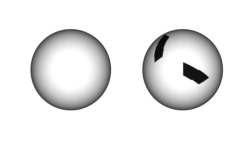

In [120]:
# try a more complicated patch
patch_ids = np.concatenate([np.arange(1000, 1500), np.arange(12500, 13000)])
patch_map = np.zeros((solver.n_verts,))
patch_map[patch_ids] = 1
plot_surf(sphere_path, patch_map, cmap='binary')

In [124]:
iter_verts = karcher_mean(solver.geometry, init_vert, patch_ids, n_iters=20, heatsolver=heatsolver)

Done computing heat solver and tangent frames.
Done initializing tree and current vertex.
Iter 1/20
Iter 2/20
Iter 3/20
Iter 4/20
Iter 5/20
Iter 6/20
Iter 7/20
Iter 8/20
Iter 9/20
Iter 10/20
Iter 11/20
Iter 12/20
Iter 13/20
Iter 14/20
Iter 15/20
Iter 16/20
Iter 17/20
Iter 18/20
Iter 19/20
Iter 20/20


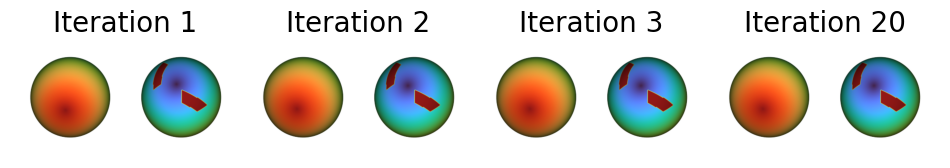

In [127]:
plot_idx = [0, 1, 2, len(iter_verts)-1]

heats = diffusion(solver.geometry, [[vert] for vert in iter_verts])
dists = compute_geodesic_f(solver.geometry, heats)
dists[patch_ids] = np.max(dists) + 1
plot_surf(sphere_path, dists[:, plot_idx], labels=[f'Iteration {i+1}' for i in plot_idx], cmap='turbo')

### Cortex

In [ ]:
solver = EigenSolver(cortex_path)
heatsolver = pp3d.MeshVectorHeatSolver(solver.geometry.v, solver.geometry.t)

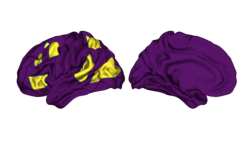

In [194]:
patch_ids = np.concatenate([np.arange(9000, 10000), np.arange(11000, 11800), np.arange(14000, 16000), np.arange(30000, 30300), np.arange(30600, 30900)])
patch_map = np.zeros((solver.n_verts,))
patch_map[patch_ids] = 1
plot_surf(cortex_path, patch_map, cmap='viridis')

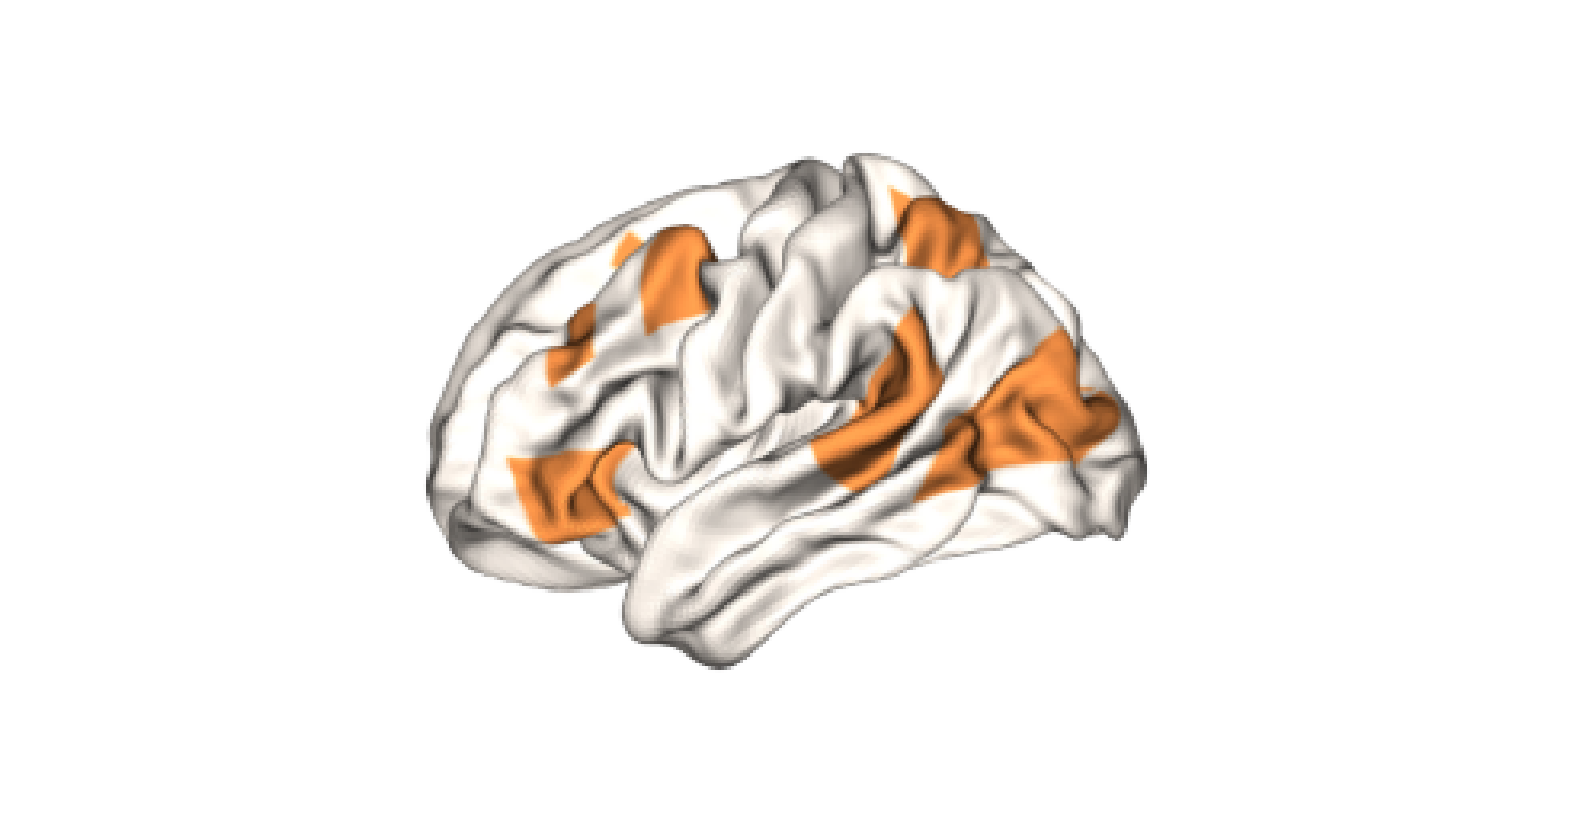

In [209]:
fig, ax = plt.subplots(figsize=(20, 20))
patch_map[0] = 2  # hack to adjust the cmap range
plot_surf(cortex_path, patch_map, cmap='Oranges', views='lateral', ax=ax)
plt.show()

In [195]:
iter_verts = karcher_mean(solver.geometry, patch_ids, init_vert=0, n_iters=20, heatsolver=heatsolver)

Done computing heat solver and tangent frames.
Done initializing tree and current vertex.
Iter 1/20
Iter 2/20
Iter 3/20
Iter 4/20
Iter 5/20
Iter 6/20
Iter 7/20
Iter 8/20
Iter 9/20
Iter 10/20
Iter 11/20
Iter 12/20
Iter 13/20
Iter 14/20
Iter 15/20
Iter 16/20
Iter 17/20
Iter 18/20
Iter 19/20
Iter 20/20


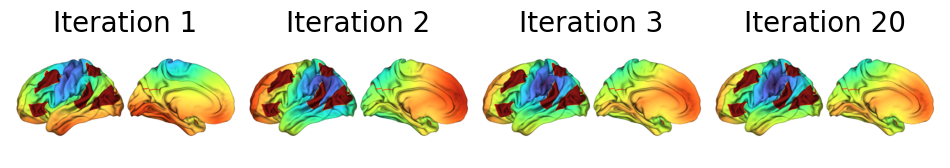

In [149]:
dists = compute_geodesic_f(solver.geometry, diffusion(solver.geometry, [[vert] for vert in iter_verts]))
dists[patch_ids] = np.max(dists) + 1
plot_surf(cortex_path, dists[:, plot_idx], labels=[f'Iteration {i+1}' for i in plot_idx], cmap='turbo')

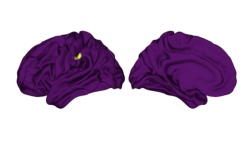

In [197]:
# plot the final vertex on the surface
n_nearest = 100
final_vert_map = np.zeros((solver.n_verts,))

# use tree to get n_nearest vertices to the final vertex and plot them
tree = cKDTree(solver.geometry.v)
final_vert = iter_verts[-1]
nearest_verts = tree.query(solver.geometry.v[final_vert], k=n_nearest)[1]
final_vert_map[nearest_verts] = 1
plot_surf(cortex_path, final_vert_map, cmap='viridis')

In [216]:
# plot full overlay
full_map = compute_geodesic_f(solver.geometry, diffusion(solver.geometry, [iter_verts[-1]]))

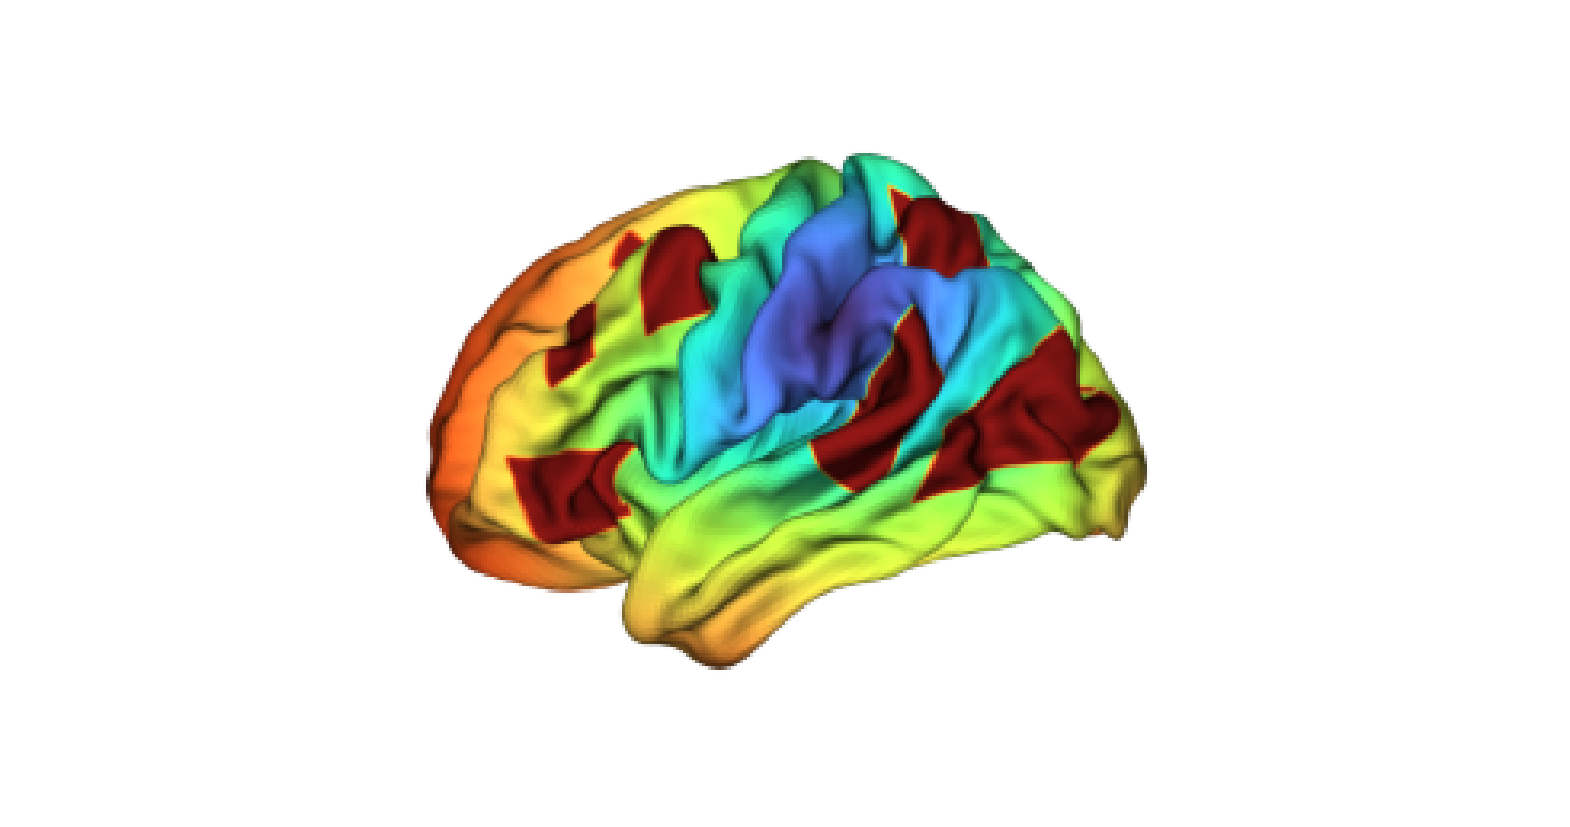

In [217]:
fig, ax = plt.subplots(figsize=(20, 20))
full_map[patch_ids] = np.max(full_map) + 1
#full_map[nearest_verts] = np.max(full_map) + 100
plot = plot_surf(cortex_path, full_map, cmap='turbo', views='lateral', ax=ax)
plt.show()